In [147]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [148]:
data = pd.read_csv("train.csv")

In [149]:
data

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [150]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

In [151]:
data['age'] = data['age'].fillna(data['age'].mean())
data['daily_screen_time_hours'] = data['daily_screen_time_hours'].fillna(data['daily_screen_time_hours'].mean())
data['social_media_hours'] = data['social_media_hours'].fillna(data['social_media_hours'].mean())
data['gaming_hours'] = data['gaming_hours'].fillna(data['gaming_hours'].mean())
data['work_study_hours'] = data['work_study_hours'].fillna(data['work_study_hours'].mean())
data['sleep_hours'] = data['sleep_hours'].fillna(data['sleep_hours'].mean())
data['notifications_per_day'] = data['notifications_per_day'].fillna(data['notifications_per_day'].mean())
data['app_opens_per_day'] = data['app_opens_per_day'].fillna(data['app_opens_per_day'].mean())
data['weekend_screen_time'] = data['weekend_screen_time'].fillna(data['weekend_screen_time'].mean())
data['academic_work_impact'] = data['academic_work_impact'].fillna(data['academic_work_impact'].mode()[0])

In [152]:
from sklearn.tree import DecisionTreeClassifier

known_data = data[data['gender'].notna()]
missing_data = data[data['gender'].isna()]

features = ['social_media_hours', 'gaming_hours']
X_train = known_data[features]
y_train = known_data['gender']
X_missing = missing_data[features]

clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train)

predicted_genders = clf.predict(X_missing)
data.loc[data['gender'].isna(), 'gender'] = predicted_genders

In [153]:
from sklearn.tree import DecisionTreeClassifier

known_data = data[data['stress_level'].notna()]
missing_data = data[data['stress_level'].isna()]

features = ['social_media_hours', 'gaming_hours', 'sleep_hours', 'work_study_hours', 'notifications_per_day']
X_train = known_data[features]
y_train = known_data['stress_level']
X_missing = missing_data[features]

clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train)

predicted_stress_levels = clf.predict(X_missing)
data.loc[data['stress_level'].isna(), 'stress_level'] = predicted_stress_levels

In [154]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      691369 non-null  float64
 2   daily_screen_time_hours  691369 non-null  float64
 3   social_media_hours       691369 non-null  float64
 4   gaming_hours             691369 non-null  float64
 5   work_study_hours         691369 non-null  float64
 6   sleep_hours              691369 non-null  float64
 7   notifications_per_day    691369 non-null  float64
 8   app_opens_per_day        691369 non-null  float64
 9   weekend_screen_time      691369 non-null  float64
 10  gender                   691369 non-null  str    
 11  stress_level             691369 non-null  str    
 12  academic_work_impact     691369 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

In [155]:
from sklearn.model_selection import train_test_split
X = data.drop(['addicted_label'], axis=1)
y = data['addicted_label']

In [156]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [157]:
train_data = X_train.join(y_train)

In [158]:
train_data = train_data.join(pd.get_dummies(train_data.gender, dtype=int)).drop(['gender'], axis=1)

In [159]:
train_data['stress_level'] = train_data['stress_level'].map({'Low': 1, 'Medium': 2, 'High': 3})
train_data['academic_work_impact'] = train_data['academic_work_impact'].map({'Yes': 1, 'No': 0})

In [160]:
train_data

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addicted_label,Female,Male,Other
29933,29933,18.000000,4.15,2.200000,0.090000,1.470000,6.804334,239.0,175.000000,6.030000,2,0,1,1,0,0
64877,64877,35.000000,8.49,4.610000,0.680000,2.366971,5.830000,144.0,16.000000,12.350000,3,1,1,0,0,1
267052,267052,27.000000,9.95,3.950000,2.950000,1.070000,8.850000,33.0,140.000000,9.479866,3,1,1,1,0,0
391924,391924,21.000000,11.46,2.471038,0.060000,0.890000,8.540000,76.0,85.000000,8.630000,2,0,1,0,0,1
448851,448851,19.000000,8.98,2.820000,0.060000,1.380000,4.570000,33.0,19.000000,11.840000,3,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627516,627516,19.000000,5.11,1.350000,1.480000,2.020000,8.680000,223.0,68.000000,4.630000,3,0,0,0,0,1
155510,155510,27.000000,9.07,2.830000,3.020000,2.250000,8.070000,184.0,124.000000,13.460000,1,1,1,1,0,0
607068,607068,20.000000,10.99,1.210000,1.800000,3.210000,7.300000,81.0,91.000000,11.330000,2,1,1,0,0,1
159952,159952,26.615408,5.73,2.471038,1.750000,2.970000,7.640000,99.0,21.000000,9.479866,3,1,0,0,0,1


array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'daily_screen_time_hours'}>,
        <Axes: title={'center': 'social_media_hours'}>],
       [<Axes: title={'center': 'gaming_hours'}>,
        <Axes: title={'center': 'work_study_hours'}>,
        <Axes: title={'center': 'sleep_hours'}>,
        <Axes: title={'center': 'notifications_per_day'}>],
       [<Axes: title={'center': 'app_opens_per_day'}>,
        <Axes: title={'center': 'weekend_screen_time'}>,
        <Axes: title={'center': 'stress_level'}>,
        <Axes: title={'center': 'academic_work_impact'}>],
       [<Axes: title={'center': 'addicted_label'}>,
        <Axes: title={'center': 'Female'}>,
        <Axes: title={'center': 'Male'}>,
        <Axes: title={'center': 'Other'}>]], dtype=object)

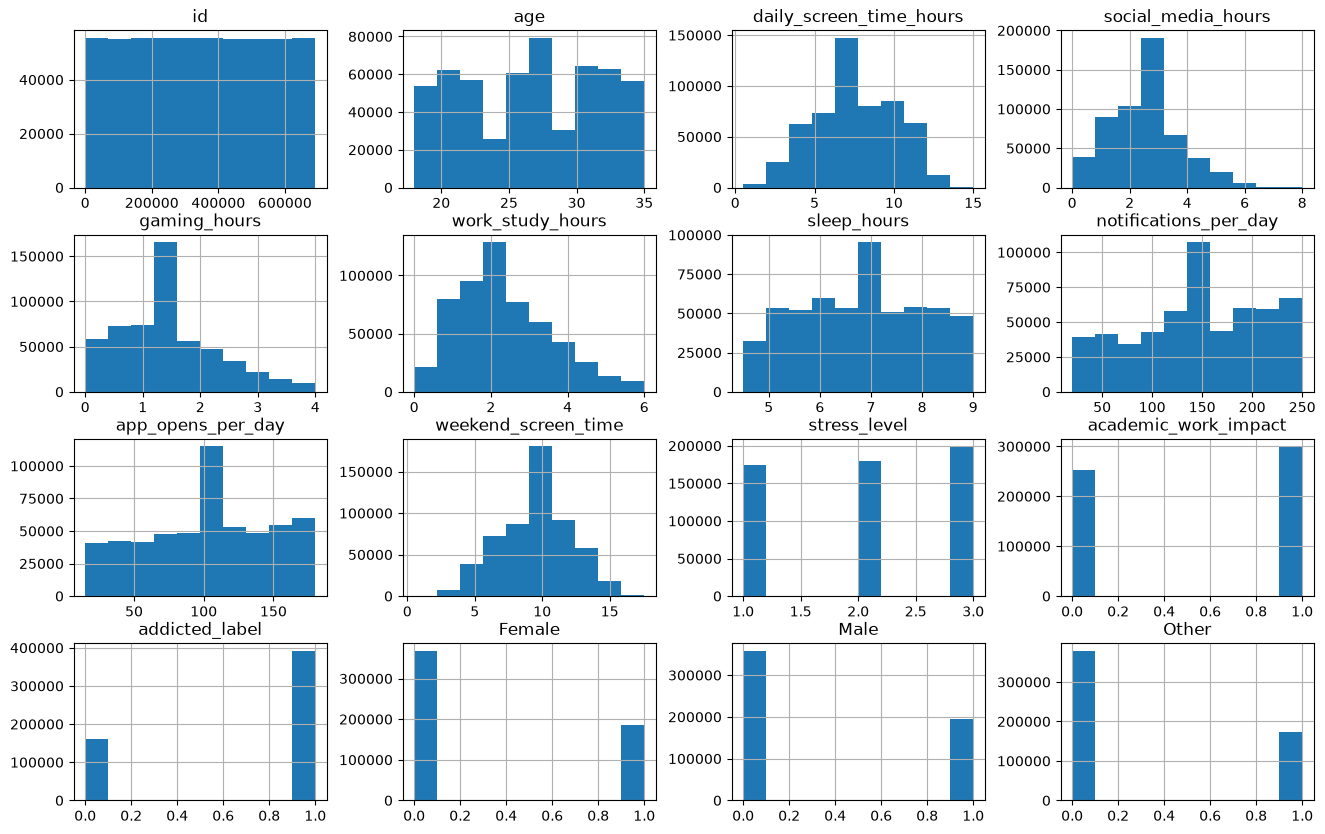

In [161]:
train_data.hist(figsize=(16,10))

<Axes: >

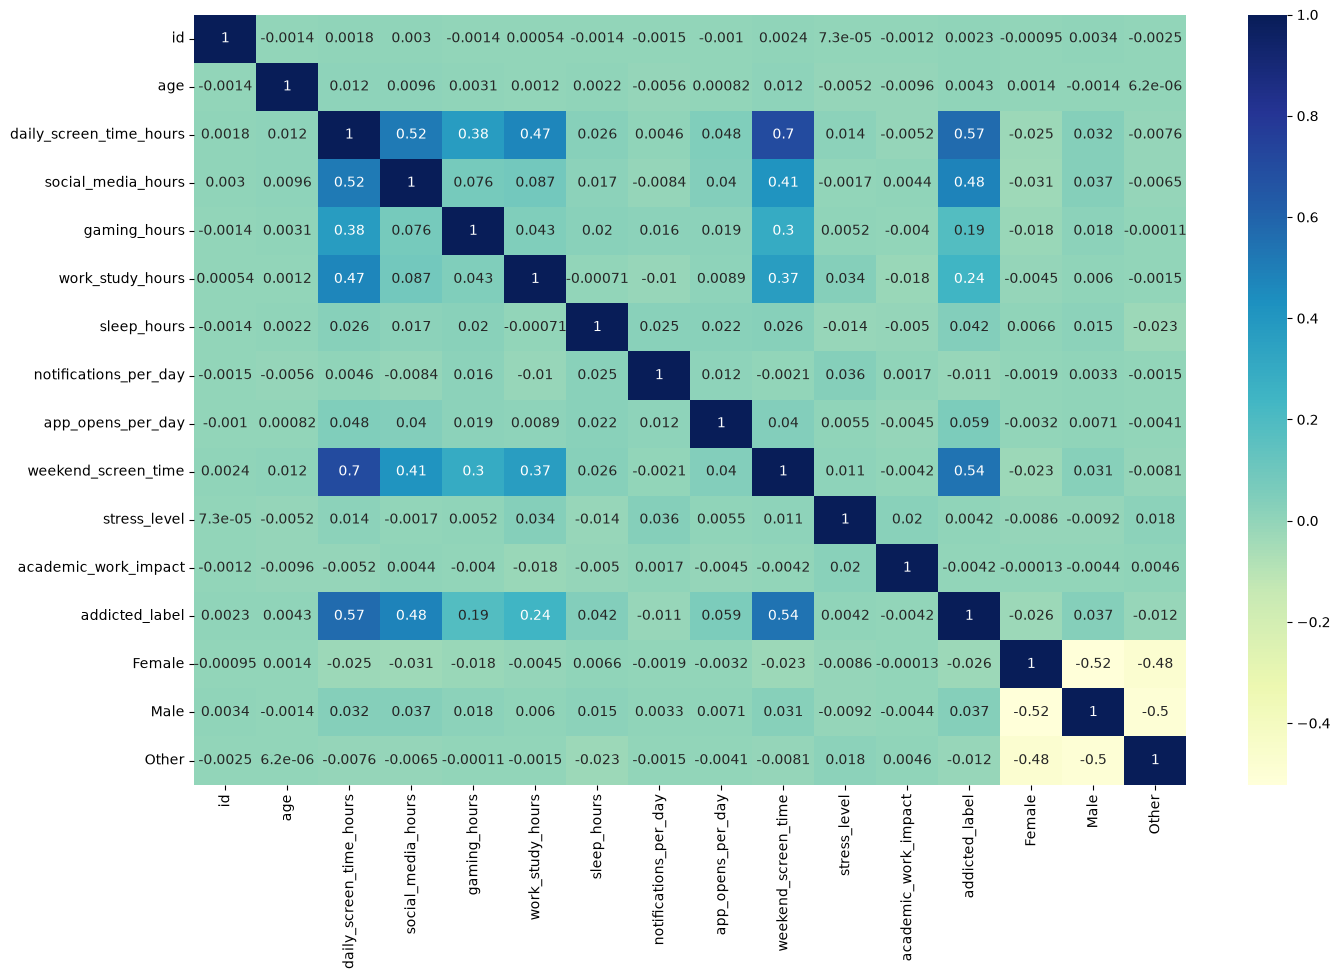

In [162]:
plt.figure(figsize=(16,10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [163]:
train_data['screen_to_sleep_ratio'] = train_data['daily_screen_time_hours'] / (train_data['sleep_hours'] + 0.1)
train_data['social_media_share'] = train_data['social_media_hours'] / (train_data['daily_screen_time_hours'] + 0.1)
train_data['gaming_share'] = train_data['gaming_hours'] / (train_data['daily_screen_time_hours'] + 0.1)

In [167]:
def preprocess(data):
    data = data.copy()
    data = data.join(pd.get_dummies(data.gender, dtype=int)).drop(columns=['gender'])
    data['stress_level'] = data['stress_level'].map({'Low': 1, 'Medium': 2, 'High': 3})
    data['academic_work_impact'] = data['academic_work_impact'].map({'Yes': 1, 'No': 0})
    data['screen_to_sleep_ratio'] = data['daily_screen_time_hours'] / (data['sleep_hours'] + 0.1)
    data['social_media_share'] = data['social_media_hours'] / (data['daily_screen_time_hours'] + 0.1)
    data['gaming_share'] = data['gaming_hours'] / (data['daily_screen_time_hours'] + 0.1)
    return data


X_train_p = preprocess(X_train)
# make sure test has exactly the same columns, in the same order
X_test_p = preprocess(X_test).reindex(columns=X_train_p.columns, fill_value=0)


In [168]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_p, y_train)

accuracy = model.score(X_test_p, y_test)
print(f"Logistic Regression Accuracy: {accuracy: .4f}")

Logistic Regression Accuracy:  0.8248


c:\Users\Majdi\OneDrive\Skrivbord\Phone_addiction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [175]:
from sklearn.metrics import classification_report

predictions_logistic_reg = model.predict(X_test_p)
print(classification_report(y_test, predictions_logistic_reg))


              precision    recall  f1-score   support

           0       0.74      0.61      0.67     40116
           1       0.85      0.91      0.88     98158

    accuracy                           0.82    138274
   macro avg       0.80      0.76      0.77    138274
weighted avg       0.82      0.82      0.82    138274



In [173]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train_p, y_train)

tree_accuracy = clf.score(X_test_p, y_test)
print(f"Decision Tree Accuracy: {tree_accuracy: .4f}")

Decision Tree Accuracy:  0.8503


In [176]:
from sklearn.metrics import classification_report

predictions_decision_tree = clf.predict(X_test_p)
print(classification_report(y_test, predictions_decision_tree))

              precision    recall  f1-score   support

           0       0.76      0.71      0.73     40116
           1       0.89      0.91      0.90     98158

    accuracy                           0.85    138274
   macro avg       0.82      0.81      0.82    138274
weighted avg       0.85      0.85      0.85    138274



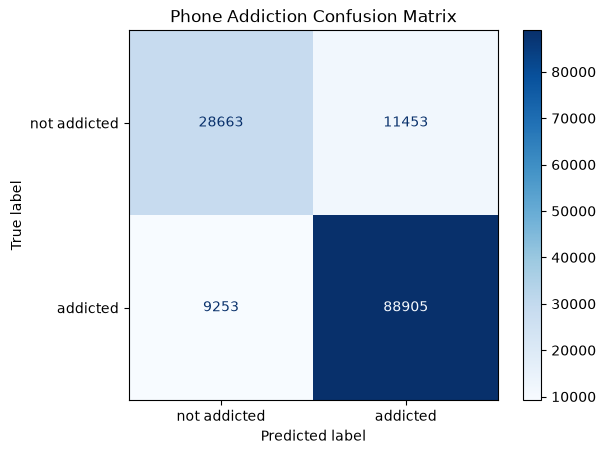

In [177]:
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions_decision_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not addicted', 'addicted'])

disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title('Phone Addiction Confusion Matrix')
plt.show()

In [ ]:
new_test_data = pd.read_csv('test.csv')
X_new_p = preprocess(new_test_data).reindex(columns=X_train_p.columns, fill_value=0)

final_predictions = clf.predict_proba(X_new_p)
addicted_probabilities = final_predictions[:, 1]

# Save to a new clean CSV file
submission_df = pd.DataFrame({
    'id': new_test_data['id'] if 'id' in new_test_data.columns else new_test_data.index,
    'addicted_label': final_predictions
})

submission_df.to_csv('my_predictions.csv', index=False)
print("Predictions saved successfully to 'my_predictions.csv'!")



Predictions saved successfully to 'my_predictions.csv'!
